In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_excel("donnees_ventes_ML.xlsx")

# Analyse Exploratoire des Données (EDA)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409839 entries, 0 to 409917
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                409839 non-null  int64  
 1   RevenuAnnuel       409839 non-null  int64  
 2   ScoreCredit        409839 non-null  int64  
 3   NbVisitesSite      409839 non-null  int64  
 4   PanierMoyen        409839 non-null  float64
 5   DepensesAnnuelles  409839 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 21.9 MB


In [66]:
df.columns

Index(['Age', 'RevenuAnnuel', 'ScoreCredit', 'NbVisitesSite', 'PanierMoyen',
       'DepensesAnnuelles'],
      dtype='object')

In [15]:
df.head().round(2)

,Age,RevenuAnnuel,ScoreCredit,NbVisitesSite,PanierMoyen,DepensesAnnuelles
0,46,69,370,13,29.0,2.38
1,38,77,392,30,19.0,2.81
2,48,103,478,42,50.0,3.31
3,58,90,350,26,44.0,3.27
4,37,56,390,32,10.0,2.07


In [21]:
df.describe().round(2)

,Age,RevenuAnnuel,ScoreCredit,NbVisitesSite,PanierMoyen,DepensesAnnuelles
count,409918.00,409918.00,409918.00,409918.00,409845.00,409898.00
mean,40.13,75.25,377.12,39.69,51.87,2.94
std,11.59,20.78,52.69,38.62,29.88,1.08
min,18.00,20.00,300.00,1.00,10.00,0.00
25%,32.00,61.00,336.00,12.00,28.00,2.23
50%,40.00,75.00,375.00,28.00,50.00,2.72
75%,48.00,89.00,413.00,55.00,72.00,3.36
max,70.00,150.00,655.00,200.00,196.00,16.43


In [49]:
df.isna().any()

Age                  False
RevenuAnnuel         False
ScoreCredit          False
NbVisitesSite        False
PanierMoyen          False
DepensesAnnuelles    False
dtype: bool

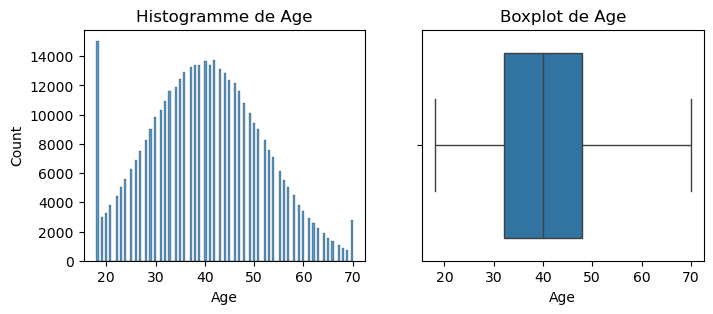

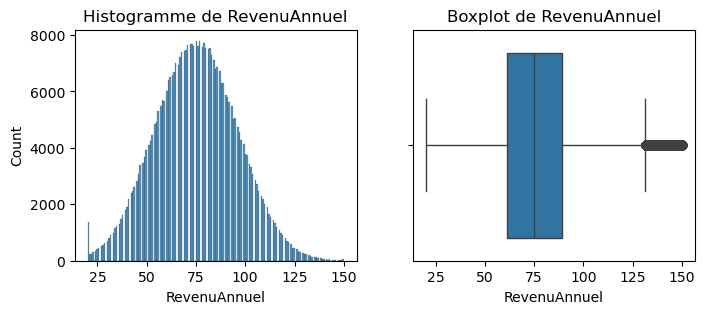

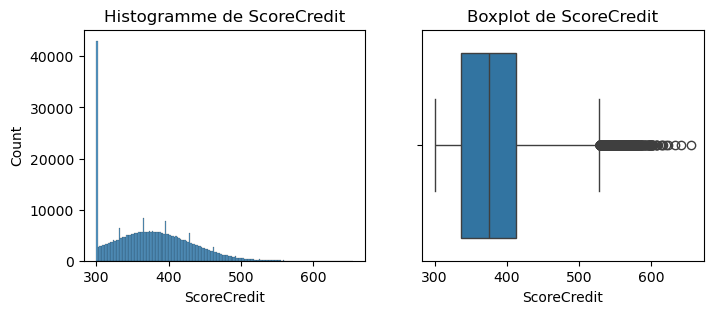

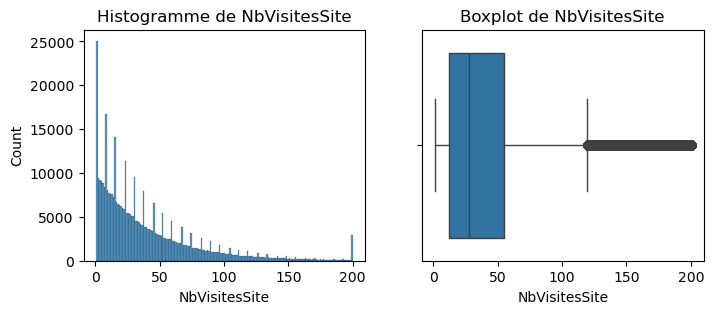

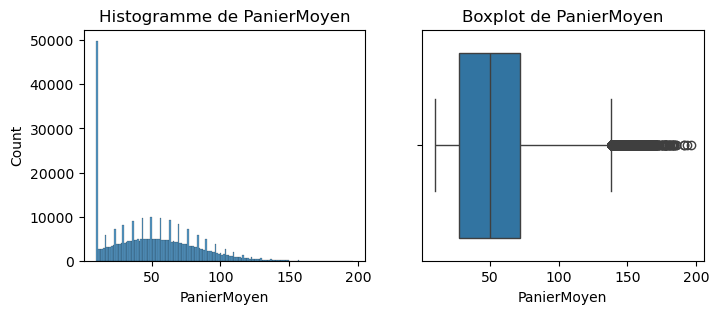

In [33]:
variables = df.columns.drop('DepensesAnnuelles')
for var in variables:
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1)
    sns.histplot(df[var], kde=False)
    plt.title(f"Histogramme de {var}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot de {var}")
    plt.show()

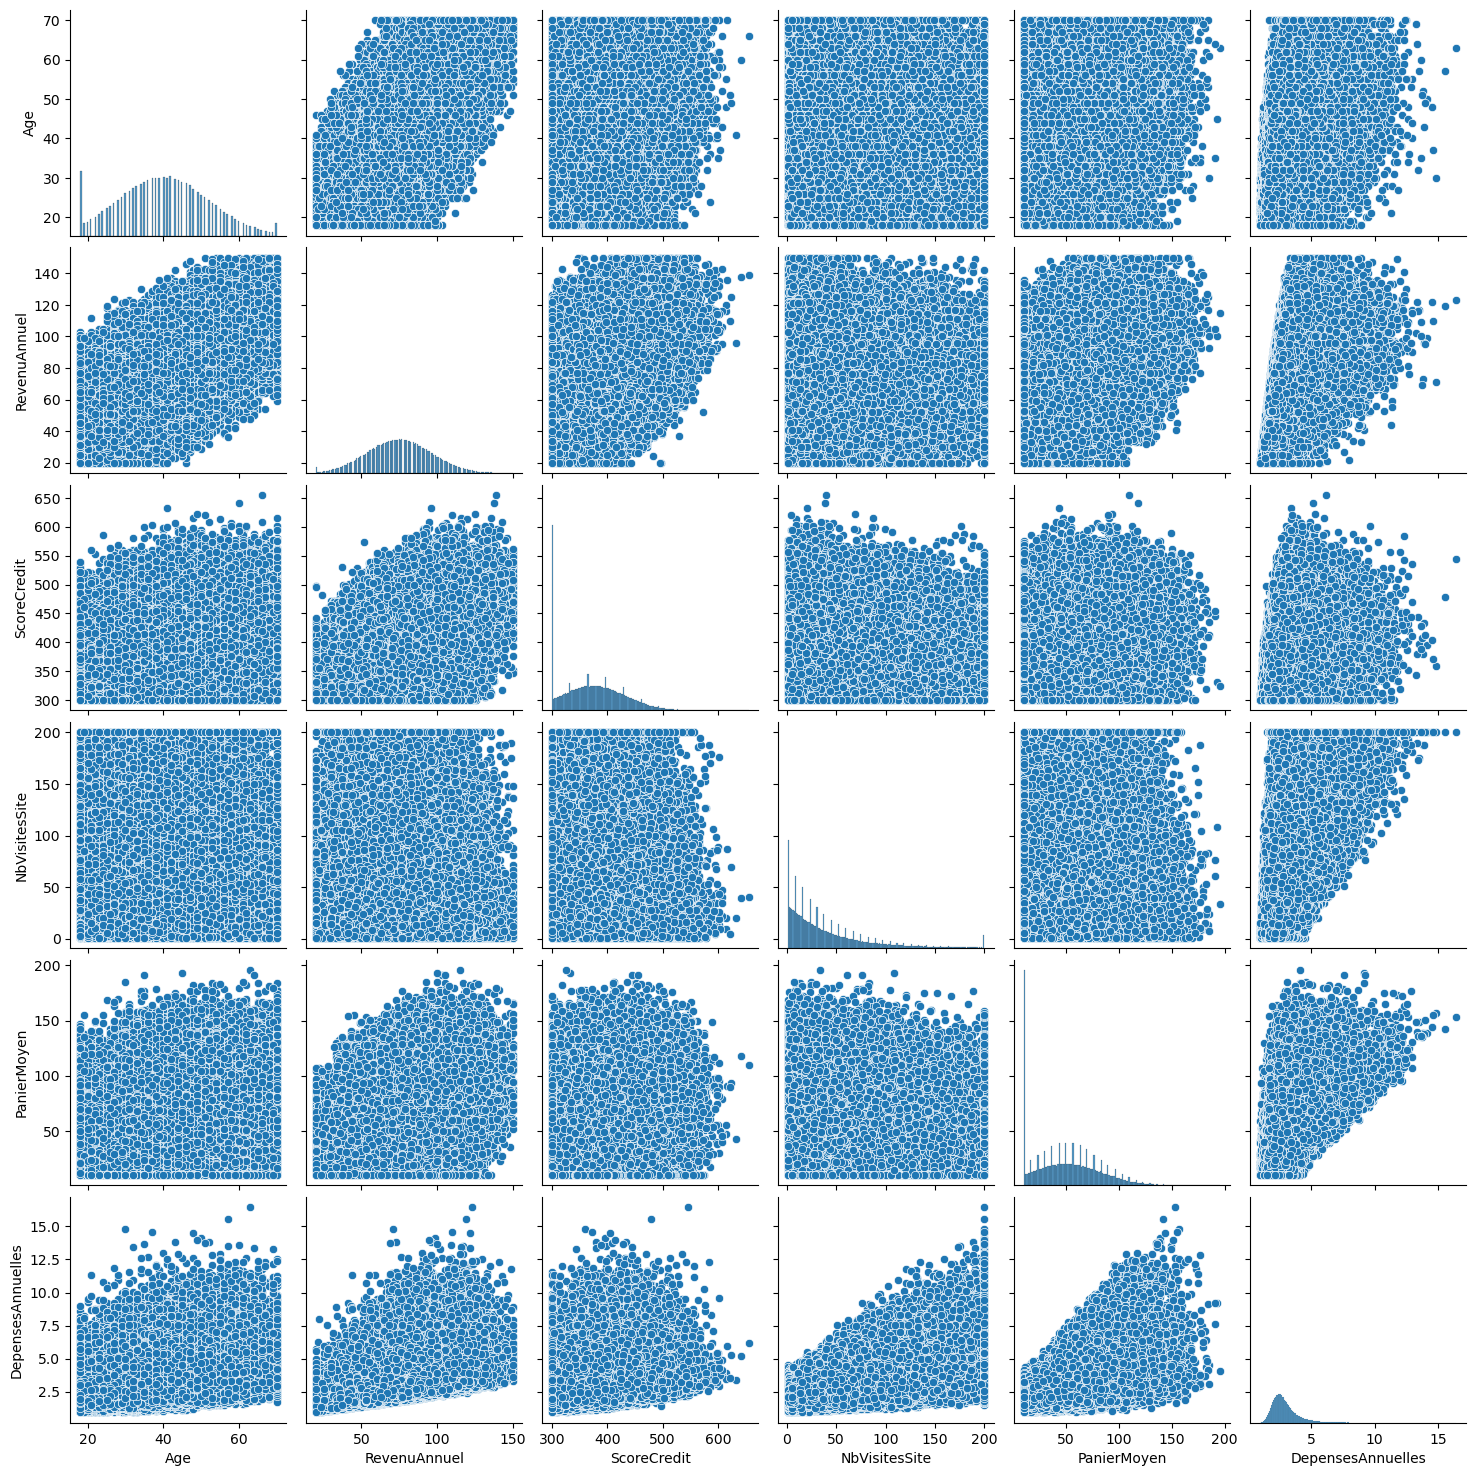

In [82]:
sns.pairplot(df, vars=['Age', 'RevenuAnnuel', 'ScoreCredit', 'NbVisitesSite', 'PanierMoyen', 'DepensesAnnuelles'])
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# Fonction pour calculer et afficher le R²
def annotate_r2(x, y, **kwargs):
    r_value, _ = stats.pearsonr(x, y)
    r_squared = r_value**2
    ax = plt.gca()
    ax.text(0.05, 0.9, f'R² = {r_squared:.2f}', transform=ax.transAxes, fontsize=12, color='red')

# Création du pairplot
g = sns.pairplot(df, vars=['Age', 'RevenuAnnuel', 'ScoreCredit', 'NbVisitesSite', 'PanierMoyen', 'DepensesAnnuelles'],
                 kind='reg')  # Ajout de la régression linéaire sur les graphiques

# Ajout de R² sur chaque graphique
for ax in g.axes.flatten():
    if ax is not None:
        x_data = ax.lines[0].get_xdata()
        y_data = ax.lines[0].get_ydata()
        annotate_r2(x_data, y_data)

plt.show()


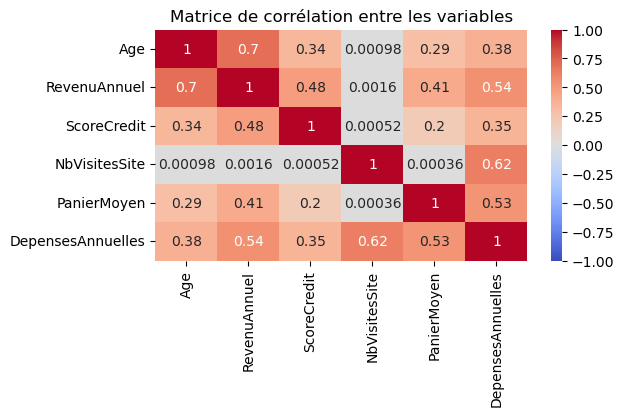


Corrélations avec DepensesAnnuelles:

DepensesAnnuelles    1.00
NbVisitesSite        0.62
RevenuAnnuel         0.54
PanierMoyen          0.53
Age                  0.38
ScoreCredit          0.35
Name: DepensesAnnuelles, dtype: float64


In [41]:
plt.figure(figsize=(6,3))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice de corrélation entre les variables')
plt.show()
print("\nCorrélations avec DepensesAnnuelles:\n")
print(df.corr()['DepensesAnnuelles'].sort_values(ascending=False).round(2))

# Préparations du dataset

In [45]:
print(df.isnull().sum())

Age                   0
RevenuAnnuel          0
ScoreCredit           0
NbVisitesSite         0
PanierMoyen          73
DepensesAnnuelles    20
dtype: int64


In [47]:
df = df.dropna()

In [68]:
# X = df.drop(columns=['DepensesAnnuelles'])
X = df[['Age', 'RevenuAnnuel', 'ScoreCredit', 'NbVisitesSite', 'PanierMoyen']]
y = df['DepensesAnnuelles']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
model = LinearRegression()
model.fit(X_train, y_train)

df_coeffs = pd.DataFrame({
    'Variables': X.columns,
    'Coefficients': model.coef_
})
print(df_coeffs.sort_values(by='Coefficients', key=abs, ascending=False))

       Variables  Coefficients
3  NbVisitesSite      0.017325
1   RevenuAnnuel      0.017159
4    PanierMoyen      0.013243
2    ScoreCredit      0.002514
0            Age      0.000310


R2 : 0.80
MSE : 0.24


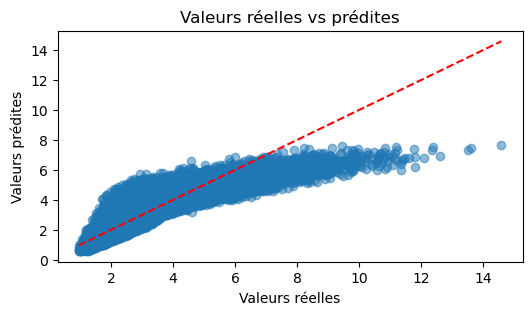

In [72]:
y_pred = model.predict(X_test)
r2     = r2_score(y_test, y_pred)
mse    = mean_squared_error(y_test, y_pred)
print(f"R2 : {r2:.2f}")
print(f"MSE : {mse:.2f}")

# (Optionnel) Scatter plot
plt.figure(figsize=(6,3))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Valeurs réelles vs prédites")
plt.show()

In [78]:
df_new = pd.read_excel(r"C:\Users\sefas\Documents\nouvelles_donnees_clients.xlsx")

predictions_new = model.predict(df_new)
df_new['DepensePredite'] = predictions_new.round(2)
df_new.to_excel('predictions_clients.xlsx', index=False)
print("\n Fichier 'predictions_clients.xlsx' généré avec succès !")


 Fichier 'predictions_clients.xlsx' généré avec succès !
